In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import cv2
import math
import time
import librosa
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
import torch
import torchaudio
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
birdclef_2025_path = kagglehub.competition_download('birdclef-2025')

print('Data source import complete.')

Data source import complete.


In [ ]:
from pathlib import Path

audio_folder = Path(birdclef_2025_path) / 'train_audio'
audio_files = list(audio_folder.rglob('*.ogg'))  # or .wav if needed
print(f'Found {len(audio_files)} audio files.')

Found 28564 audio files.


In [ ]:
import librosa

def compute_mfcc(file_path, sr=32000, n_mfcc=40):
    y, _ = librosa.load(file_path, sr=sr)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    return mfcc

In [ ]:
class Config:

    DEBUG_MODE = True

    OUTPUT_DIR = 'drive/MyDrive/working' #change as needed
    DATA_ROOT = Path(birdclef_2025_path) #change as needed
    FS = 32000
    # Mel spectrogram parameters
    N_FFT = 1024
    HOP_LENGTH = 512
    N_MELS = 128
    FMIN = 50
    FMAX = 14000
    TARGET_DURATION = 5.0 #
    TARGET_SHAPE = (256, 256)

    N_MAX = 28000 if DEBUG_MODE else None

config = Config()

In [ ]:
print(f"Debug mode: {'ON' if config.DEBUG_MODE else 'OFF'}")
print(f"Max samples to process: {config.N_MAX if config.N_MAX is not None else 'ALL'}")

print("Loading taxonomy data...")
taxonomy_df = pd.read_csv(f'{Path(birdclef_2025_path)}/taxonomy.csv')
species_class_map = dict(zip(taxonomy_df['primary_label'], taxonomy_df['class_name']))

print("Loading training metadata...")
train_df = pd.read_csv(f'{Path(birdclef_2025_path)}/train.csv')
print("done")


Debug mode: ON
Max samples to process: 28000
Loading taxonomy data...
Loading training metadata...
done


In [ ]:
label_list = sorted(train_df['primary_label'].unique())
label_id_list = list(range(len(label_list)))
label2id = dict(zip(label_list, label_id_list))
id2label = dict(zip(label_id_list, label_list))

print(f'Found {len(label_list)} unique species')
working_df = train_df[['primary_label', 'rating', 'filename']].copy()
working_df['target'] = working_df.primary_label.map(label2id)
working_df['filepath'] = working_df['filename'].apply(lambda x: Path(birdclef_2025_path) / 'train_audio' / x)
working_df['samplename'] = working_df.filename.map(lambda x: x.split('/')[0] + '-' + x.split('/')[-1].split('.')[0])
working_df['class'] = working_df.primary_label.map(lambda x: species_class_map.get(x, 'Unknown'))
total_samples = min(len(working_df), config.N_MAX or len(working_df))
print(f'Total samples to process: {total_samples} out of {len(working_df)} available')
print(f'Samples by class:')
print(working_df['class'].value_counts())

Found 206 unique species
Total samples to process: 28000 out of 28564 available
Samples by class:
class
Aves        27648
Amphibia      583
Mammalia      178
Insecta       155
Name: count, dtype: int64


In [ ]:
# === TORCH AUDIO SETUP ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mfcc_transform = torchaudio.transforms.MFCC(
    sample_rate=config.FS,
    n_mfcc=40,             # typical value for MFCCs
    melkwargs={
        'n_fft': config.N_FFT,
        'hop_length': config.HOP_LENGTH,
        'n_mels': config.N_MELS,
        'f_min': config.FMIN,
        'f_max': config.FMAX,
        'power': 2.0
    }
).to(device)

# === HELPER FUNCTION ===
def audio2mfcc(audio_data):
    if np.isnan(audio_data).any():
        mean_signal = np.nanmean(audio_data)
        audio_data = np.nan_to_num(audio_data, nan=mean_signal)

    waveform = torch.tensor(audio_data, dtype=torch.float32, device=device).unsqueeze(0)
    mfcc = mfcc_transform(waveform)

    mfcc -= mfcc.min()
    mfcc /= mfcc.max() + 1e-8

    return mfcc.squeeze(0).cpu().numpy()

# === SAVE DIRECTORY SETUP ===
SAVE_DIR = os.path.join(config.OUTPUT_DIR, "mfccs")
os.makedirs(SAVE_DIR, exist_ok=True)

# === MAIN PROCESSING LOOP ===
print("Starting audio processing...")
print(f"{'DEBUG MODE - Processing only 50 samples' if config.DEBUG_MODE else 'FULL MODE - Processing all samples'}")
start_time = time.time()

all_bird_data = {}
errors = []

# must define working_df and total_samples before this loop
# working_df = pd.read_csv(...) or however you're loading it
# total_samples = len(working_df)

for i, row in tqdm(working_df.iterrows(), total=total_samples):
    if config.N_MAX is not None and i >= config.N_MAX:
        break
    try:
        audio_data, _ = librosa.load(row.filepath, sr=config.FS)
        target_samples = int(config.TARGET_DURATION * config.FS)

        if len(audio_data) < target_samples:
            audio_data = np.tile(audio_data, int(np.ceil(target_samples / len(audio_data))))
        center_audio = audio_data[:target_samples]

        if len(center_audio) < target_samples:
            center_audio = np.pad(center_audio, (0, target_samples - len(center_audio)))

        mel_spec = audio2mfcc(center_audio)

        if mel_spec.shape != config.TARGET_SHAPE:
            mel_spec = cv2.resize(mel_spec, config.TARGET_SHAPE, interpolation=cv2.INTER_LINEAR)

        mel_spec = mel_spec.astype(np.float32)
        all_bird_data[row.samplename] = mel_spec

        # === Save as .npy in class-specific subfolder ===
        class_folder = os.path.join(SAVE_DIR, row['class'])
        os.makedirs(class_folder, exist_ok=True)

        save_path = os.path.join(class_folder, f"{row.samplename}.npy")
        np.save(save_path, mel_spec)

    except Exception as e:
        print(f"Error processing {row.filepath}: {e}")
        errors.append((row.filepath, str(e)))

# === DONE ===
end_time = time.time()
print(f"\nProcessing completed in {end_time - start_time:.2f} seconds")
print(f"Successfully processed {len(all_bird_data)} files out of {total_samples}")
print(f"Failed to process {len(errors)} files")

Starting audio processing...
DEBUG MODE - Processing only 50 samples


  0%|          | 0/28000 [00:00<?, ?it/s]


Processing completed in 1421.62 seconds
Successfully processed 28000 files out of 28000
Failed to process 0 files


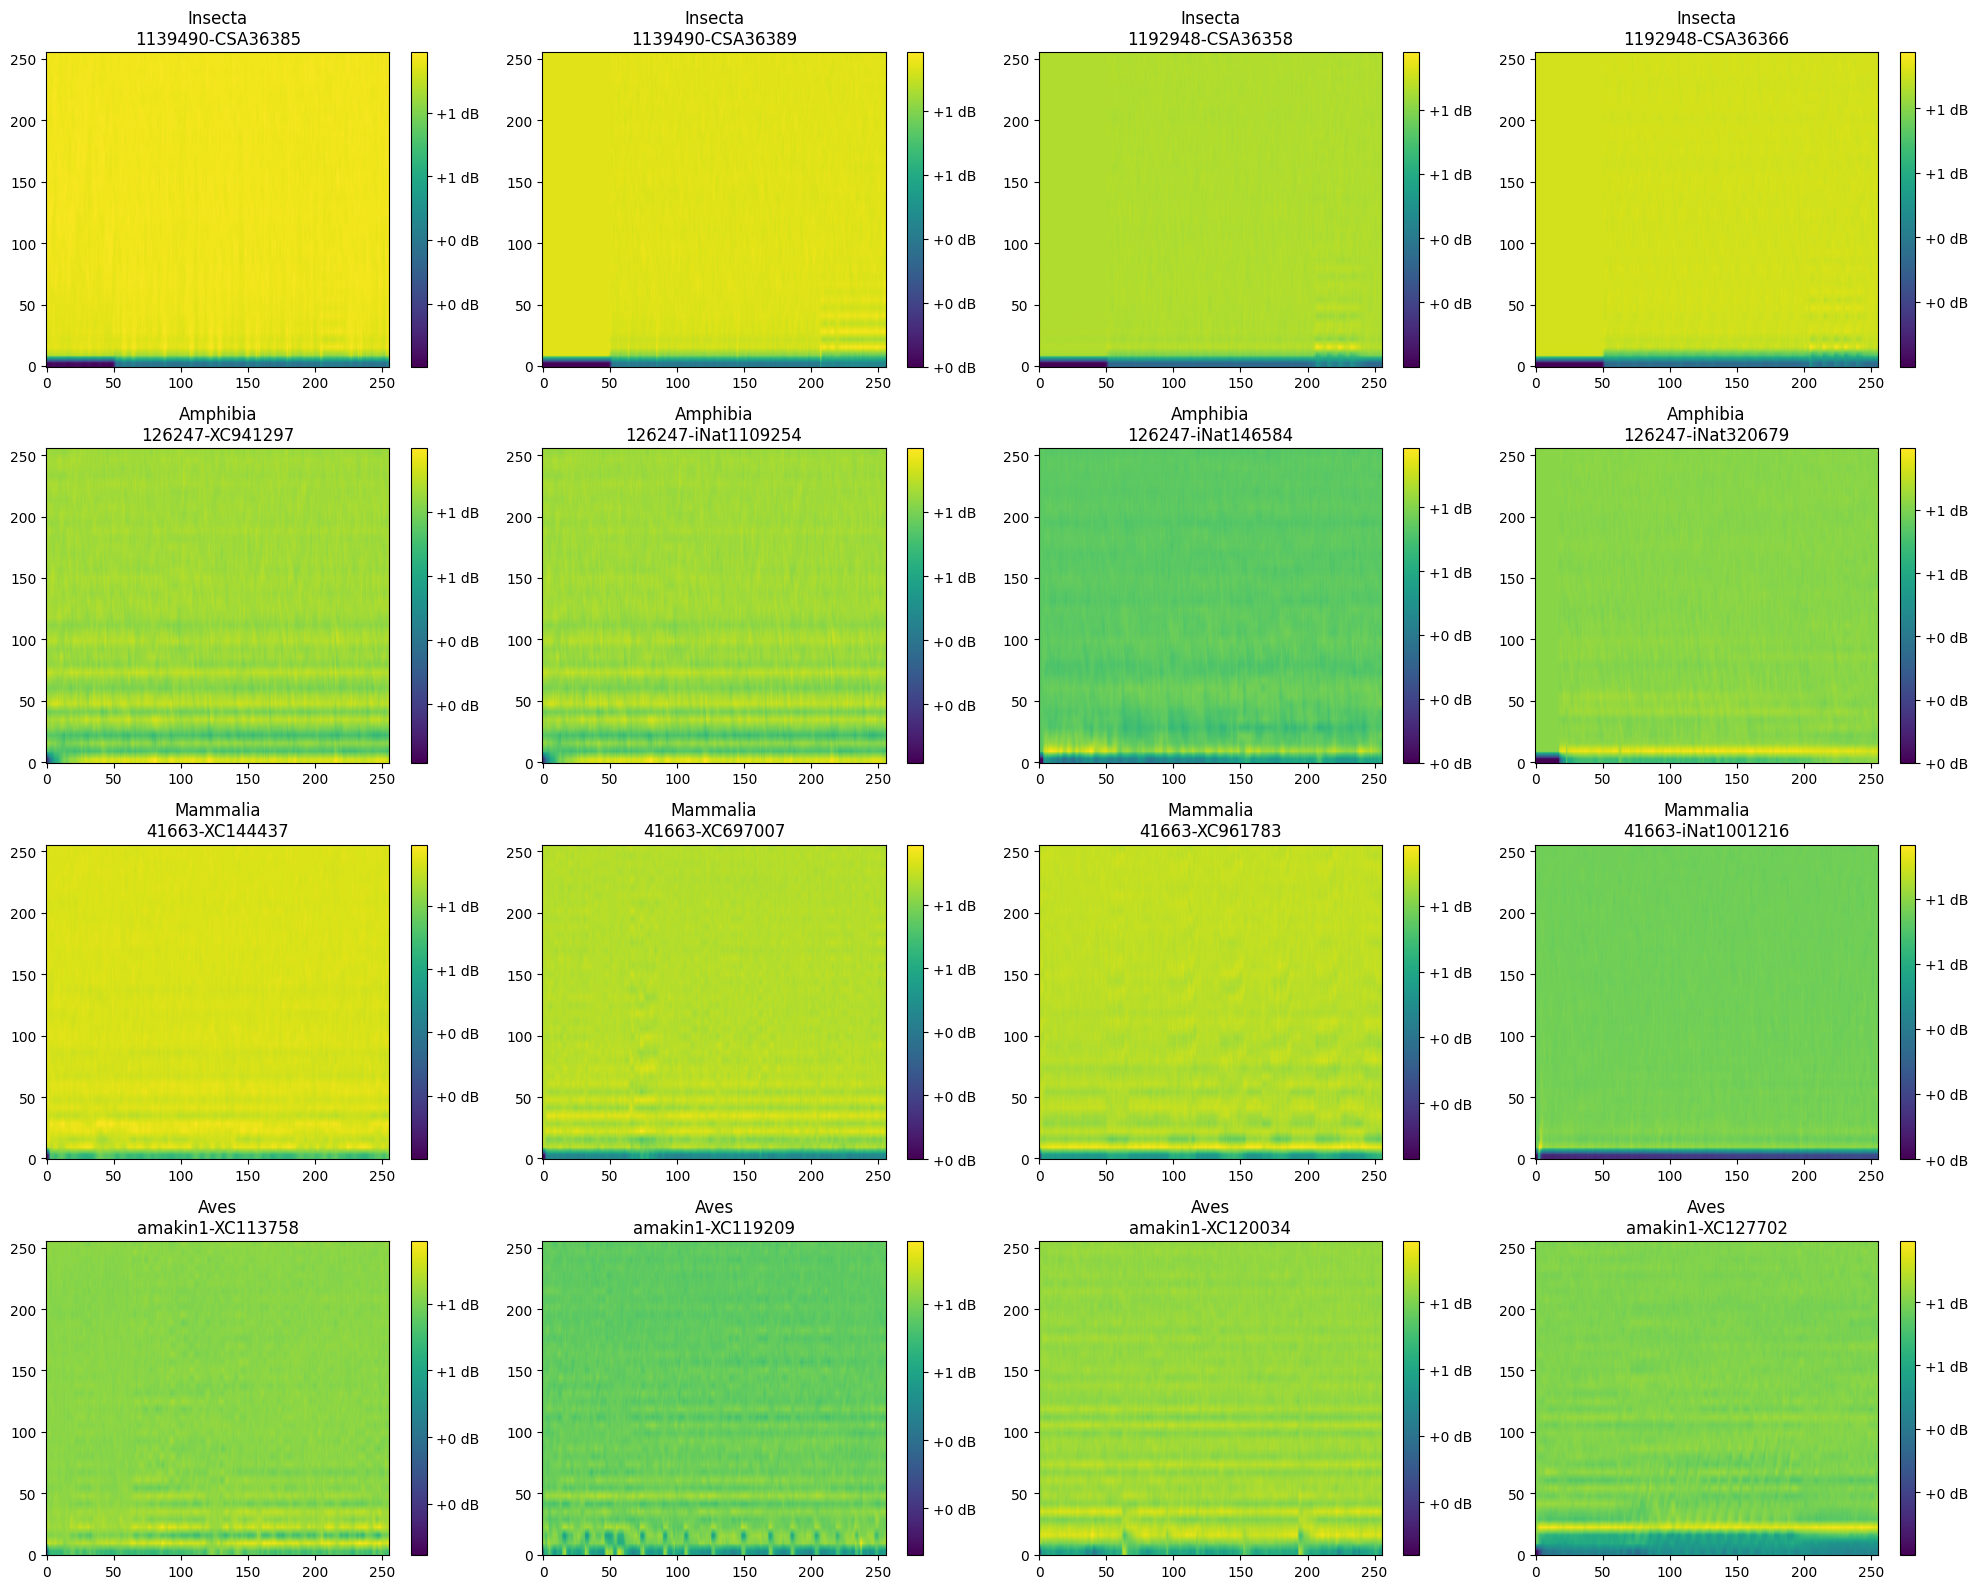

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path

# === Step 1: Setup ===
LOAD_DIR = os.path.join(config.OUTPUT_DIR, "mfccs")

class_samples = defaultdict(list)
max_classes = 4
samples_per_class = 4

# Recursively find all .npy files
npy_files = list(Path(LOAD_DIR).rglob("*.npy"))

# === Step 2: Load samples grouped by class ===
for file_path in npy_files:
    samplename = file_path.stem
    class_name = file_path.parent.name  # subfolder name = class

    if len(class_samples[class_name]) < samples_per_class:
        mel = np.load(file_path, mmap_mode='r')
        class_samples[class_name].append((samplename, mel))

    # Stop if we have enough samples
    if len(class_samples) >= max_classes and all(len(v) >= samples_per_class for v in class_samples.values()):
        break

# === Step 3: Plot ===
plt.figure(figsize=(samples_per_class * 5, max_classes * 4))

plot_index = 1
for class_name, items in list(class_samples.items())[:max_classes]:
    for samplename, mel_spec in items:
        plt.subplot(max_classes, samples_per_class, plot_index)
        plt.imshow(mel_spec, aspect='auto', origin='lower', cmap='viridis')
        plt.title(f"{class_name}\n{samplename}")
        plt.colorbar(format='%+2.0f dB')
        plot_index += 1

plt.tight_layout()
plt.show()

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from torchvision import models
import joblib
import pandas as pd
from torch.optim.lr_scheduler import ReduceLROnPlateau
# === CONFIGURATION ===
class Config:
    OUTPUT_DIR = 'drive/MyDrive/working'
    BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, "best_model.pt")

config = Config()

# === DATASET ===
class MFCCDataset(Dataset):
    def __init__(self, data_dict, label_dict):
        self.samples = list(data_dict.keys())
        self.data_dict = data_dict
        self.label_dict = label_dict

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        samplename = self.samples[idx]
        mfcc = self.data_dict[samplename]
        label = self.label_dict[samplename]
        mfcc_tensor = torch.tensor(mfcc, dtype=torch.float32).unsqueeze(0)
        label_tensor = torch.tensor(label, dtype=torch.long)
        return mfcc_tensor, label_tensor

# === MODEL ===
class MelCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2)
        )
        self.adaptive_pool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential(
            nn.Dropout(),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

    def predict(self, x):
        self.eval()
        with torch.no_grad():
            logits = self(x)
            return torch.argmax(logits, dim=1)

class MelResNet(nn.Module):
    def __init__(self, num_classes, backbone_name="resnet34"):
        super().__init__()

        # Choose backbone based on the name
        if backbone_name == "resnet18":
            self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        elif backbone_name == "resnet34":
            self.backbone = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
        elif backbone_name == "resnet50":
            self.backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        elif backbone_name == "resnet101":
            self.backbone = models.resnet101(weights=models.ResNet101_Weights.DEFAULT)
        elif backbone_name == "resnet152":
            self.backbone = models.resnet152(weights=models.ResNet152_Weights.DEFAULT)
        else:
            raise ValueError(f"Unknown backbone: {backbone_name}")

        # Adjust the first conv layer for 1 channel input
        self.backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

        # Replace the final fully connected layer
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

    def predict(self, x):
        self.eval()
        with torch.no_grad():
            logits = self(x)
            return torch.argmax(logits, dim=1)

def load_file(file):
    samplename = file.stem
    species_id = samplename.split("-")[0]

    # Just load the MFCC array
    mfcc = np.load(file,mmap_mode="r")  # <-- DIRECTLY load it, no librosa, no compute_mfcc

    return samplename, mfcc, species_id

def load_data_structure_parallel(root_dir, max_workers=4):
    loaded_data = {}
    sample_to_label = {}

    files = [file for class_dir in Path(root_dir).iterdir() if class_dir.is_dir()
             for file in class_dir.glob("*.npy")]

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        future_to_file = {executor.submit(load_file, file): file for file in files}
        for future in as_completed(future_to_file):
            samplename, mel_spec, species_id = future.result()
            loaded_data[samplename] = mel_spec
            sample_to_label[samplename] = species_id

    return loaded_data, sample_to_label

def prepare_dataloaders(data_dict, label_dict, batch_size, train_names=None, val_names=None, label_encoder=None):
    # Only keep samples that are present in both data_dict and label_dict
    available_samples = sorted(set(label_dict.keys()) & set(data_dict.keys()))

    if label_encoder is None:
        label_encoder = LabelEncoder()
        label_encoder.fit(list(label_dict.values()))

    sample_to_encoded = {
        sample_name: label_encoder.transform([label_dict[sample_name]])[0]
        for sample_name in available_samples
    }

    # If train/val names provided, filter them too
    if train_names is not None and val_names is not None:
        train_names = [k for k in train_names if k in data_dict]
        val_names = [k for k in val_names if k in data_dict]
    else:
        train_names, val_names = train_test_split(available_samples, test_size=0.2, random_state=42)

    # Final check — all names should be in data_dict and sample_to_encoded
    train_data = {k: data_dict[k] for k in train_names}
    val_data = {k: data_dict[k] for k in val_names}
    train_labels = {k: sample_to_encoded[k] for k in train_names}
    val_labels = {k: sample_to_encoded[k] for k in val_names}

    train_ds = MFCCDataset(train_data, train_labels)
    val_ds = MFCCDataset(val_data, val_labels)
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    val_dl = DataLoader(val_ds, batch_size=batch_size)

    return train_dl, val_dl, len(label_encoder.classes_), label_encoder




# === EVALUATION ===
def evaluate_roc_auc(model, dataloader, device, num_classes):
    model.eval()
    all_probs = []
    all_targets = []

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            probs = F.softmax(logits, dim=1)
            all_probs.append(probs.cpu().numpy())
            all_targets.append(y.cpu().numpy())

    all_probs = np.concatenate(all_probs, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)
    y_true = label_binarize(all_targets, classes=np.arange(num_classes))
    scored_classes = np.where(y_true.sum(axis=0) > 0)[0]

    if len(scored_classes) == 0:
        return 0.0

    try:
        return roc_auc_score(y_true[:, scored_classes], all_probs[:, scored_classes], average="macro")
    except ValueError:
        return 0.0

# === TRAINING ===
# def train_model(train_dl, val_dl, num_classes, model, epochs=10, lr=1e-4, save_name = "",):
#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#     #model = MelResNet(num_classes).to(device)
#     # model = MelCNN(num_classes).to(device)
#     model = model.to(device)
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr)
#     loss_fn = nn.CrossEntropyLoss()

#     auc_history = []
#     best_auc = 0.0

#     for epoch in range(epochs):
#         model.train()
#         for x, y in train_dl:
#             x, y = x.to(device), y.to(device)
#             optimizer.zero_grad()
#             loss = loss_fn(model(x), y)
#             loss.backward()
#             optimizer.step()

#         val_auc = evaluate_roc_auc(model, val_dl, device, num_classes)
#         auc_history.append(val_auc)

#         if val_auc > best_auc:
#             best_auc = val_auc
#             base = os.path.splitext(config.BEST_MODEL_PATH)[0]  # Remove ".pt"
#             new_save_path = base + "_" + save_name + ".pt"
#             torch.save(model.state_dict(), new_save_path)

#         print(f"Epoch {epoch+1}/{epochs} — ROC AUC: {val_auc:.4f} {'<-- best' if val_auc == best_auc else ''}")

#     print(f"Training complete. Best ROC AUC: {best_auc:.4f}")
#     return model, auc_history

# === SIMPLE FOCAL LOSS (no class weights) ===
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, inputs, targets):
        BCE = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-BCE)
        focal = (1 - pt) ** self.gamma * BCE
        return focal.mean()

# === TRAINING LOOP ===
def train_model(
    train_dl, val_dl, num_classes, model,
    epochs=10, lr=1e-4, save_name="",
    use_focal_loss=False, gamma=2.0
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=1)

    # === Choose loss function ===
    if use_focal_loss:
        loss_fn = FocalLoss(gamma=gamma)
    else:
        loss_fn = nn.CrossEntropyLoss()

    auc_history = []
    best_auc = 0.0

    # === Create history tracker ===
    history = {
        "epoch": [],
        "train_loss": [],
        "val_auc": [],
        "current_lr": []
    }

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for x, y in train_dl:
            x, y = x.to(device), y.to(device)

            # If using focal loss, convert y to one-hot
            if use_focal_loss:
                y = F.one_hot(y, num_classes=num_classes).float()

            optimizer.zero_grad()
            logits = model(x)
            loss = loss_fn(logits, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # Validation
        val_auc = evaluate_roc_auc(model, val_dl, device, num_classes)
        auc_history.append(val_auc)

        # Step scheduler
        scheduler.step(val_auc)
        current_lr = scheduler.optimizer.param_groups[0]['lr']

        # Update history
        history["epoch"].append(epoch + 1)
        history["train_loss"].append(total_loss)
        history["val_auc"].append(val_auc)
        history["current_lr"].append(current_lr)

        # Save best model
        if val_auc > best_auc:
            best_auc = val_auc
            base = os.path.splitext(config.BEST_MODEL_PATH)[0]
            checkpoint_path = base + "_" + save_name + ".pt"
            torch.save(model.state_dict(), checkpoint_path)

        print(f"Epoch {epoch+1}/{epochs} — Loss: {total_loss:.2f} — ROC AUC: {val_auc:.4f} — LR: {current_lr:.2e} {'<-- best' if val_auc == best_auc else ''}")

    print(f"✅ Training complete. Best ROC AUC: {best_auc:.4f}")

    # === Save training history ===
    history_df = pd.DataFrame(history)
    history_path = os.path.join(config.OUTPUT_DIR, f"training_history_{save_name}.csv")
    history_df.to_csv(history_path, index=False)
    print(f"📄 Training history saved to: {history_path}")

    return model, auc_history

# === PLOTTING ===
def plot_auc_history(auc_history):
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(auc_history) + 1), auc_history, marker='o')
    plt.title("Validation ROC AUC over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("ROC AUC")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
ROOT_DIR = Path(config.OUTPUT_DIR) / "mfccs"
print(f"Scanning: {ROOT_DIR}")
loaded_bird_data, sample_to_label = load_data_structure_parallel(ROOT_DIR)

Scanning: drive/MyDrive/working/mfccs


In [ ]:
sample_to_label['1192948-CSA36388']

'1192948'

In [ ]:
all_classes = sorted(set(sample_to_label.values()))
print(f"Total classes found: {len(all_classes)}")
print(f"First 5 classes: {all_classes[:5]}")
print(f"Total samples: {len(loaded_bird_data)}")

# use first time when you do not have train_names val_names and label_encoder
# train_dl, val_dl, num_classes, label_encoder = prepare_dataloaders(loaded_bird_data, sample_to_label, batch_size=32)

# Load saved splits
train_names = np.load(os.path.join(config.OUTPUT_DIR, "train_names.npy"), allow_pickle=True).tolist()
val_names = np.load(os.path.join(config.OUTPUT_DIR, "val_names.npy"), allow_pickle=True).tolist()

# Load label encoder
label_encoder = joblib.load(os.path.join(config.OUTPUT_DIR, "label_encoder (1).pkl"))
print("✅ Loaded LabelEncoder.")

# Pass them in
train_dl, val_dl, num_classes, label_encoder = prepare_dataloaders(
    loaded_bird_data, sample_to_label, batch_size=32,
    train_names=train_names, val_names=val_names, label_encoder=label_encoder
)

Total classes found: 205
First 5 classes: ['1139490', '1192948', '1194042', '126247', '1346504']
Total samples: 28213
✅ Loaded LabelEncoder.


In [ ]:
model_res18 = MelResNet(num_classes,backbone_name="resnet18")
#model_res50 = MelResNet(num_classes,backbone_name="resnet50")
#model_res101 = MelResNet(num_classes,backbone_name="resnet101")
#model_alex_1 = MelCNN(num_classes)

In [ ]:
# For ResNet18
_, auc_history_res18 = train_model(train_dl, val_dl, num_classes, model_res18, save_name="res18_20_ep",epochs=20)

Epoch 1/20 — Loss: 2726.64 — ROC AUC: 0.8723 — LR: 1.00e-04 <-- best
Epoch 2/20 — Loss: 1820.34 — ROC AUC: 0.9261 — LR: 1.00e-04 <-- best
Epoch 3/20 — Loss: 1400.93 — ROC AUC: 0.9484 — LR: 1.00e-04 <-- best
Epoch 4/20 — Loss: 1088.57 — ROC AUC: 0.9434 — LR: 1.00e-04 
Epoch 5/20 — Loss: 803.06 — ROC AUC: 0.9271 — LR: 5.00e-05 
Epoch 6/20 — Loss: 440.80 — ROC AUC: 0.9621 — LR: 5.00e-05 <-- best
Epoch 7/20 — Loss: 281.92 — ROC AUC: 0.9597 — LR: 5.00e-05 
Epoch 8/20 — Loss: 168.85 — ROC AUC: 0.9502 — LR: 2.50e-05 
Epoch 9/20 — Loss: 84.16 — ROC AUC: 0.9596 — LR: 2.50e-05 
Epoch 10/20 — Loss: 60.31 — ROC AUC: 0.9604 — LR: 1.25e-05 
Epoch 11/20 — Loss: 43.01 — ROC AUC: 0.9607 — LR: 1.25e-05 
Epoch 12/20 — Loss: 36.40 — ROC AUC: 0.9597 — LR: 6.25e-06 
Epoch 13/20 — Loss: 30.78 — ROC AUC: 0.9604 — LR: 6.25e-06 
Epoch 14/20 — Loss: 26.34 — ROC AUC: 0.9588 — LR: 3.13e-06 
Epoch 15/20 — Loss: 25.41 — ROC AUC: 0.9584 — LR: 3.13e-06 
Epoch 16/20 — Loss: 22.20 — ROC AUC: 0.9596 — LR: 1.56e-06 
Epoch

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

class MelResNetInference(nn.Module):
    def __init__(self, num_classes, backbone_name="resnet18"):
        super().__init__()

        # Choose backbone based on the name (no pretrained weights)
        if backbone_name == "resnet18":
            self.backbone = models.resnet18(weights=None)
        elif backbone_name == "resnet34":
            self.backbone = models.resnet34(weights=None)
        elif backbone_name == "resnet50":
            self.backbone = models.resnet50(weights=None)
        elif backbone_name == "resnet101":
            self.backbone = models.resnet101(weights=None)
        elif backbone_name == "resnet152":
            self.backbone = models.resnet152(weights=None)
        else:
            raise ValueError(f"Unknown backbone: {backbone_name}")

        # Adjust the first conv layer for 1-channel input
        self.backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

        # Replace the final fully connected layer
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

    def predict(self, x):
        self.eval()
        with torch.no_grad():
            logits = self(x)
            return torch.argmax(logits, dim=1)

    @classmethod
    def load_from_checkpoint(cls, checkpoint_path, num_classes, backbone_name="resnet18"):
        model = cls(num_classes, backbone_name=backbone_name)
        model.load_state_dict(torch.load(checkpoint_path, map_location="cpu"))
        model.eval()
        return model


Model Accuracies on Validation Set:
ResNet18: 0.6220


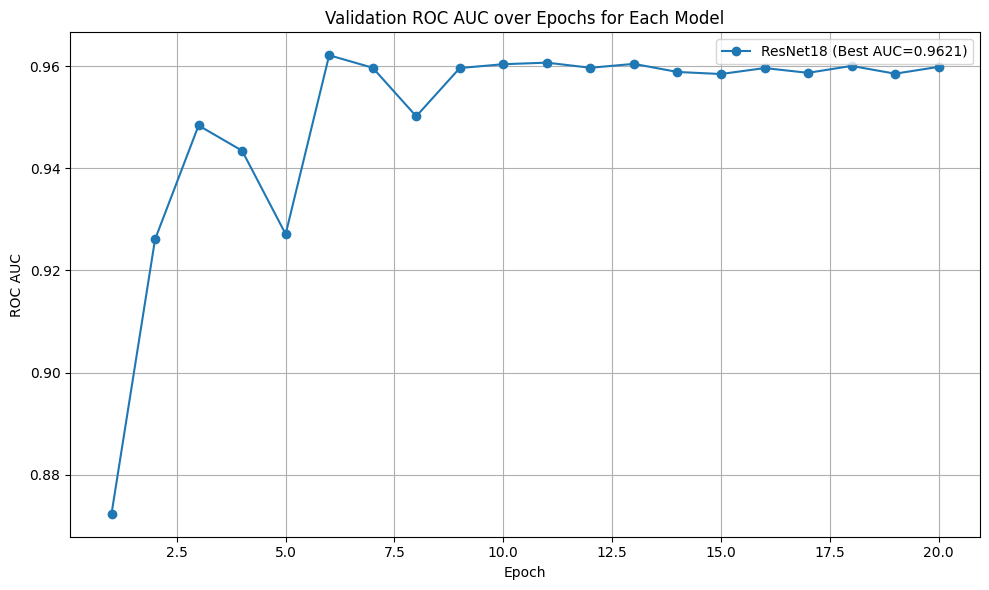

In [ ]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Your AUC histories
histories = {
    "ResNet18": auc_history_res18,
}

# Your models (make sure they're loaded and moved to device)
models = {
    "ResNet18": model_res18,
}

# Calculate accuracies
def evaluate_accuracy(model, val_dl, device='cuda'):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in val_dl:
            inputs, labels = batch
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    acc = accuracy_score(all_labels.numpy(), all_preds.numpy())
    return acc

print("Model Accuracies on Validation Set:")
for model_name, model in models.items():
    acc = evaluate_accuracy(model, val_dl)
    print(f"{model_name}: {acc:.4f}")

# Plot AUC curves
plt.figure(figsize=(10, 6))

for model_name, auc_history in histories.items():
    epochs = range(1, len(auc_history) + 1)
    best_auc = max(auc_history)
    plt.plot(epochs, auc_history, marker='o', label=f"{model_name} (Best AUC={best_auc:.4f})")

plt.title("Validation ROC AUC over Epochs for Each Model")
plt.xlabel("Epoch")
plt.ylabel("ROC AUC")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
##### NEED TO USE THIS WHEN LOADING THE RESNET MODELs AFTER TRAINING OR YOU WILL LOSE A FEW LAYER'S WIEGHTS
import torch
import torch.nn as nn
from torchvision import models

class MelResNetInference(nn.Module):
    def __init__(self, num_classes, backbone_name="resnet18"):
        super().__init__()

        # Choose backbone based on the name (no pretrained weights)
        if backbone_name == "resnet18":
            self.backbone = models.resnet18(weights=None)
        elif backbone_name == "resnet34":
            self.backbone = models.resnet34(weights=None)
        elif backbone_name == "resnet50":
            self.backbone = models.resnet50(weights=None)
        elif backbone_name == "resnet101":
            self.backbone = models.resnet101(weights=None)
        elif backbone_name == "resnet152":
            self.backbone = models.resnet152(weights=None)
        else:
            raise ValueError(f"Unknown backbone: {backbone_name}")

        # Adjust the first conv layer for 1-channel input
        self.backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

        # Replace the final fully connected layer
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

    def predict(self, x):
        self.eval()
        with torch.no_grad():
            logits = self(x)
            return torch.argmax(logits, dim=1)

    @classmethod
    def load_from_checkpoint(cls, checkpoint_path, num_classes, backbone_name="resnet18"):
        model = cls(num_classes, backbone_name=backbone_name)
        model.load_state_dict(torch.load(checkpoint_path, map_location="cpu"))
        model.eval()
        return model


# This shows how to load in the models. Note you will need

In [ ]:
import torch

# Paths to your saved best models
checkpoint_paths = {
    "resnet18": "drive/MyDrive/working/best_model_res18_20_ep.pt",
}

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load models properly
model_res18_load = MelResNetInference.load_from_checkpoint(
    checkpoint_path=checkpoint_paths["resnet18"],
    num_classes=num_classes,
    backbone_name="resnet18"
)

"""model_res50_load = MelResNetInference.load_from_checkpoint(
    checkpoint_path=checkpoint_paths["resnet50"],
    num_classes=num_classes,
    backbone_name="resnet50"
)

model_res101_load = MelResNetInference.load_from_checkpoint(
    checkpoint_path=checkpoint_paths["resnet101"],
    num_classes=num_classes,
    backbone_name="resnet101"
)

# AlexNet-style CNN loading (separate because it’s not ResNet)
model_alex_1_load = MelCNN(num_classes)
model_alex_1_load.load_state_dict(torch.load(checkpoint_paths["alexnet"], map_location="cpu"))
model_alex_1_load.eval()
"""

# Move models to device
model_res18_load = model_res18_load.to(device)
#model_res50_load = model_res50_load.to(device)
#model_res101_load = model_res101_load.to(device)
#model_alex_1_load = model_alex_1_load.to(device)

# Evaluate models
roc_auc_res18 = evaluate_roc_auc(model_res18_load, val_dl, device, num_classes)
#roc_auc_res50 = evaluate_roc_auc(model_res50_load, val_dl, device, num_classes)
#roc_auc_res101 = evaluate_roc_auc(model_res101_load, val_dl, device, num_classes)
#roc_auc_alex = evaluate_roc_auc(model_alex_1_load, val_dl, device, num_classes)

# Print results
print(f"ResNet18 Validation ROC AUC: {roc_auc_res18:.4f}")
#print(f"ResNet50 Validation ROC AUC: {roc_auc_res50:.4f}")
#print(f"ResNet101 Validation ROC AUC: {roc_auc_res101:.4f}")
#print(f"AlexNet-style Validation ROC AUC: {roc_auc_alex:.4f}")


ResNet18 Validation ROC AUC: 0.9621


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import torch

def plot_confusion_matrix_top_classes(model, val_dl, num_classes, device, label_encoder, top_n=5, bottom_n=None):
    """
    Predicts on val_dl, builds confusion matrix, and plots top-N or bottom-N classes based on frequency.

    Args:
        model: Trained PyTorch model.
        val_dl: Validation DataLoader.
        num_classes: Total number of classes.
        device: Torch device ("cpu" or "cuda").
        label_encoder: LabelEncoder instance used during training.
        top_n: Number of most common classes to visualize (if bottom_n is None).
        bottom_n: Number of least common classes to visualize (overrides top_n if given).
    """
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for mel_batch, label_batch in val_dl:
            mel_batch = mel_batch.to(device)
            preds = model.predict(mel_batch)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(label_batch.numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    # Build confusion matrix
    cm = confusion_matrix(all_labels, all_preds, labels=np.arange(num_classes))

    # Normalize confusion matrix
    cm_norm = cm.astype('float') / (cm.sum(axis=1, keepdims=True) + 1e-6)

    # Select classes based on top_n or bottom_n
    class_counts = np.bincount(all_labels, minlength=num_classes)

    # Only consider classes that appear at least once
    valid_classes = np.where(class_counts > 0)[0]

    if bottom_n is not None:
        # Among valid classes, pick the bottom_n least frequent
        sorted_valid = np.argsort(class_counts[valid_classes])
        selected_classes = valid_classes[sorted_valid[:bottom_n]]
        title_suffix = f"Bottom {bottom_n} Classes (with at least 1 sample)"
    else:
        sorted_valid = np.argsort(class_counts[valid_classes])
        selected_classes = valid_classes[sorted_valid[-top_n:]]
        title_suffix = f"Top {top_n} Classes"

    # Extract submatrix for selected classes
    cm_selected = cm_norm[np.ix_(selected_classes, selected_classes)]

    # Get real class labels from LabelEncoder
    selected_class_labels = [label_encoder.inverse_transform([i])[0] for i in selected_classes]

    # Plot
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_selected, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=selected_class_labels, yticklabels=selected_class_labels)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Normalized Confusion Matrix ({title_suffix})")
    plt.tight_layout()
    plt.show()


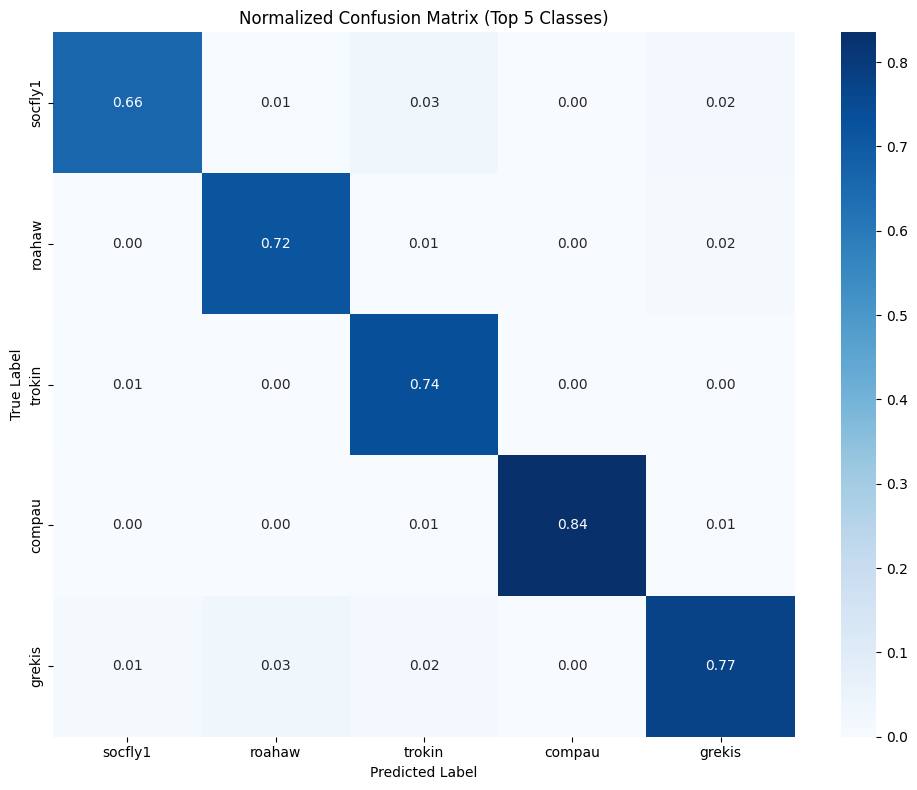

In [ ]:
plot_confusion_matrix_top_classes(model_res18_load, val_dl, num_classes, device, label_encoder, top_n=5)

As you can see, with normal training, classes with few samples are never predicted because there are too few. I was using Focal Loss to address this with good results (but that is in another notebook not to confuse anyone). We can rerun this if we want with Focal Loss training, let me know.

This confusion matrix is correct — these classes are just not mixed up with one another; they are simply predicted as other, more common classes all of the time.

In [ ]:
import numpy as np
import os

# Extract sample names from datasets
train_names = train_dl.dataset.samples
val_names = val_dl.dataset.samples

# Save them
np.save(os.path.join(config.OUTPUT_DIR, "train_names.npy"), np.array(train_names))
np.save(os.path.join(config.OUTPUT_DIR, "val_names.npy"), np.array(val_names))

print(f"Saved {len(train_names)} training samples and {len(val_names)} validation samples.")
import joblib

# Save label encoder
joblib.dump(label_encoder, os.path.join(config.OUTPUT_DIR, "label_encoder.pkl"))
print("✅ Saved LabelEncoder.")


Saved 22851 training samples and 5713 validation samples.
✅ Saved LabelEncoder.


In [ ]:
import numpy as np
import os

def save_val_dl(val_dl, save_dir):
    """
    Save full val_dl sample names and labels to disk.
    """
    save_path = os.path.join(save_dir, "val_dl_full.npz")

    sample_names = val_dl.dataset.samples
    labels = [label.item() for _, label in val_dl.dataset]  # extract labels

    np.savez_compressed(save_path, sample_names=sample_names, labels=labels)

    print(f"✅ Saved validation dataset ({len(sample_names)} samples) to {save_path}")
save_val_dl(val_dl, config.OUTPUT_DIR)


✅ Saved validation dataset (5713 samples) to working/val_dl_full.npz
